In [ ]:
import sys

print(sys.executable)

C:\Users\devis\OneDrive\Desktop\churn-prediction\.venv\Scripts\python.exe


In [12]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nModels path:")
print(os.path.abspath("../models"))

print("\nDoes models folder exist?")
print(os.path.exists("../models"))

print("\nFiles inside models:")
print(os.listdir("../models") if os.path.exists("../models") else "Folder not found")

Current working directory:
C:\Users\devis\OneDrive\Desktop\churn-prediction

Models path:
C:\Users\devis\OneDrive\Desktop\models

Does models folder exist?
True

Files inside models:
['ohe.pkl', 'scaler.pkl']


In [2]:
import os
import json
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

# 1. Initialize Repository Folder Structure
directories = [
    '../data/raw', '../data/processed', '../notebooks', '../src', 
    '../models', '../logs', '../outputs', '../configs', '../reports'
]
for directory in directories:
    os.makedirs(directory, exist_ok=True)
    
print("Project directory structure initialized!")

Project directory structure initialized!


## 1.Load Dataset and Inspect Dataset

In [3]:
# Load the raw data

df = pd.read_csv("C:\\Users\\devis\\OneDrive\\Desktop\\churn-prediction\\data\\raw\\Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check target distribution
print("--- Churn Distribution ---")
print(df["Churn"].value_counts())

class_distribution = df["Churn"].value_counts(normalize=True) * 100
print("\n--- Churn Percentages ---")
print(class_distribution)

--- Churn Distribution ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Churn Percentages ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


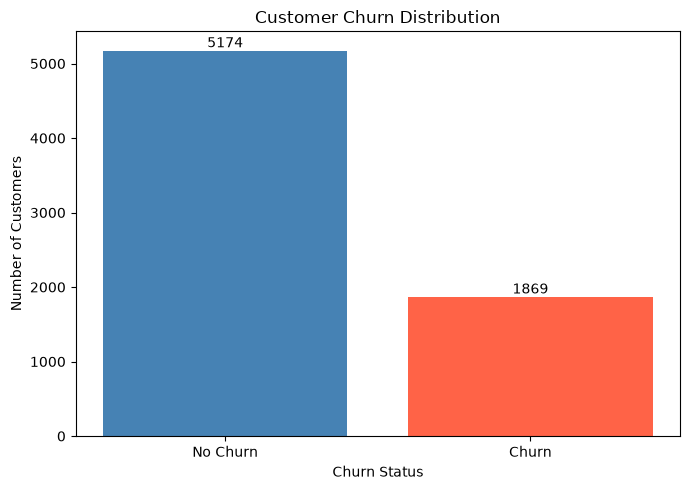

In [5]:
# Plot churn distribution
churn_counts = df["Churn"].value_counts()
churn_labels = ["No Churn", "Churn"]

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_labels, churn_counts.values, color=["steelblue", "tomato"])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 2. Preprocessing & Data Cleaning
Handling missing values, dropping redundant columns, and encoding the target variable.

### Checking for Missing/Blank TotalCharges Values

In [8]:
blank_totalcharges = df[
    df["TotalCharges"].astype(str).str.strip() == ""
]

print("Number of blank TotalCharges:", len(blank_totalcharges))

Number of blank TotalCharges: 11


In [9]:
blank_totalcharges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [10]:
# Handle blank strings in TotalCharges by coercing to NaN and filling with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop redundant ID column
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Encode Target Variable (Yes -> 1, No -> 0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0) 

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'] 

print("Data cleaning complete!")

Data cleaning complete!


In [13]:
# ==========================================
# Train-Test Split and Data Preprocessing
# ==========================================

# 1. Train-Test Split
# Splitting first helps us avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2. Separate Numerical and Categorical Columns
cat_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns

num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

# 3. Scale Numerical Features
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(
    X_train[num_cols]
)

x_test_scaled = scaler.transform(
    X_test[num_cols]
)

# 4. One-Hot Encode Categorical Features
ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

x_train_encoded = ohe.fit_transform(
    X_train[cat_cols]
)

x_test_encoded = ohe.transform(
    X_test[cat_cols]
)

# 5. Combine Numerical and Categorical Features
X_train_final = np.hstack(
    (x_train_scaled, x_train_encoded)
)

X_test_final = np.hstack(
    (x_test_scaled, x_test_encoded)
)

# ==========================================
# Save Processed Data
# ==========================================

np.save(
    'data/processed/X_train_final.npy',
    X_train_final
)

np.save(
    'data/processed/X_test_final.npy',
    X_test_final
)

np.save(
    'data/processed/y_train.npy',
    y_train.values
)

np.save(
    'data/processed/y_test.npy',
    y_test.values
)

# ==========================================
# Save Preprocessors
# ==========================================

joblib.dump(
    scaler,
    'models/scaler.pkl'
)

joblib.dump(
    ohe,
    'models/ohe.pkl'
)

# ==========================================
# Generate and Save Metadata
# ==========================================

metadata = {
    "dataset_name": "Telco Customer Churn",
    "train_shape": X_train_final.shape,
    "test_shape": X_test_final.shape,
    "numerical_features": list(num_cols),
    "categorical_features": list(cat_cols)
}

with open(
    'data/processed/dataset_metadata.json',
    'w'
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

# ==========================================
# Confirmation
# ==========================================

print("Data preprocessing completed successfully!")
print("Processed data, scaler, encoder, and metadata saved to disk.")
print()
print("Training data shape:", X_train_final.shape)
print("Testing data shape:", X_test_final.shape)

Data preprocessing completed successfully!
Processed data, scaler, encoder, and metadata saved to disk.

Training data shape: (5634, 30)
Testing data shape: (1409, 30)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand customer characteristics, churn patterns, feature distributions, and relationships between customer attributes and churn.

In [14]:
# ==========================================
# EDA - Dataset Overview
# ==========================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (7043, 20)

Column Names:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Missing Values:
gender              0
SeniorCitizen       0
P

### Churn Distribution After Data Cleaning

In [15]:
# ==========================================
# Churn Distribution After Cleaning
# ==========================================

churn_counts = df["Churn"].value_counts()

print("Churn Counts:")
print(churn_counts)

print("\nChurn Percentages:")
print((churn_counts / len(df) * 100).round(2))

Churn Counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Percentages:
Churn
0    73.46
1    26.54
Name: count, dtype: float64


### Churn Rate by Contract Type

In [16]:
# ==========================================
# Churn Rate by Contract Type
# ==========================================

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn               0      1
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


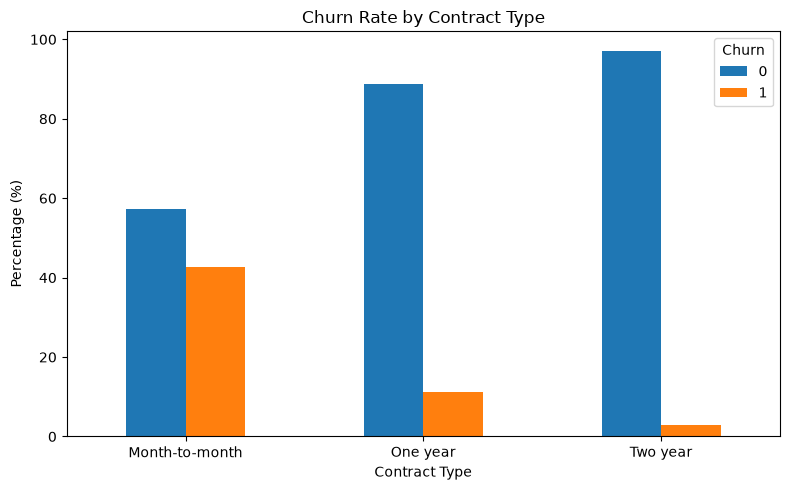

In [17]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### EDA Finding: Contract Type and Churn

The analysis shows a strong association between contract type and customer churn. The observed churn rate is 42.71% for month-to-month contracts, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

This suggests that contract type may be an important predictive feature for customer churn. However, this analysis shows association rather than causation.

### Churn Rate by Customer Tenure

In [18]:
# ==========================================
# Churn Rate by Customer Tenure
# ==========================================

tenure_churn = pd.crosstab(
    df["tenure"],
    df["Churn"],
    normalize="index"
) * 100

# Display selected tenure values
print(tenure_churn.round(2).head(20))

Churn        0      1
tenure               
0       100.00   0.00
1        38.01  61.99
2        48.32  51.68
3        53.00  47.00
4        52.84  47.16
5        51.88  48.12
6        63.64  36.36
7        61.07  38.93
8        65.85  34.15
9        61.34  38.66
10       61.21  38.79
11       68.69  31.31
12       67.52  32.48
13       65.14  34.86
14       68.42  31.58
15       62.63  37.37
16       65.00  35.00
17       70.11  29.89
18       75.26  24.74
19       73.97  26.03


### Churn Rate by Tenure Group

In [19]:
# ==========================================
# Churn Rate by Tenure Group
# ==========================================

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months",
        "49-60 months",
        "61-72 months"
    ]
)

tenure_group_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_group_churn.round(2))

Churn             0      1
TenureGroup               
0-12 months   52.56  47.44
13-24 months  71.29  28.71
25-36 months  78.37  21.63
37-48 months  80.97  19.03
49-60 months  85.58  14.42
61-72 months  93.39   6.61


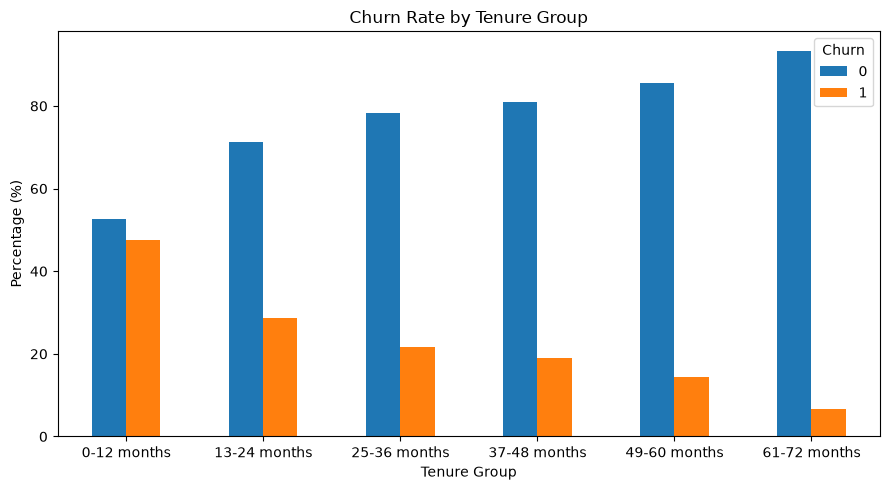

In [20]:
tenure_group_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### EDA Finding: Tenure and Churn

The analysis shows a strong association between customer tenure and churn. Customers with 0–12 months of tenure have an observed churn rate of 47.44%, while customers with 61–72 months of tenure have a churn rate of only 6.61%.

Overall, the observed churn rate decreases as customer tenure increases. This suggests that tenure may be an important predictive feature for the churn prediction model.

This analysis indicates association and does not establish causation.

### Churn Rate by Monthly Charges

In [21]:
# ==========================================
# Churn Rate by Monthly Charges
# ==========================================

df["MonthlyChargesGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    duplicates="drop"
)

monthly_charges_churn = pd.crosstab(
    df["MonthlyChargesGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(monthly_charges_churn.round(2))

Churn                    0      1
MonthlyChargesGroup              
(18.249, 35.5]       88.76  11.24
(35.5, 70.35]        75.42  24.58
(70.35, 89.85]       62.49  37.51
(89.85, 118.75]      67.12  32.88


### EDA Finding: Monthly Charges and Churn

The analysis shows that churn rates vary across monthly-charge groups. The lowest-charge group ($18.249–$35.50) has an observed churn rate of 11.24%, while the $70.35–$89.85 group has the highest observed churn rate at 37.51%.

The relationship is not strictly increasing because the highest-charge group has a lower churn rate of 32.88%. Therefore, monthly charges appear to be associated with churn, but the relationship is not simply linear or monotonic.

### Churn Rate by Internet Service

In [22]:
# ==========================================
# Churn Rate by Internet Service
# ==========================================

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn                0      1
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


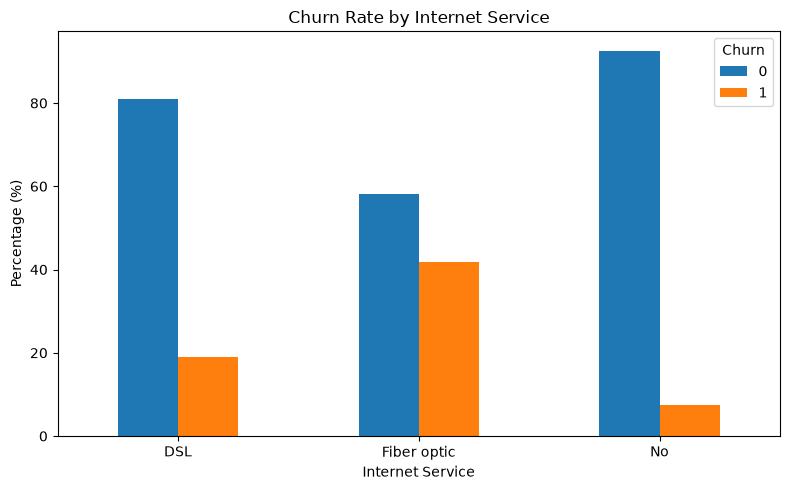

In [23]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### EDA Finding: Internet Service and Churn

The analysis shows different observed churn rates across internet service types. Fiber optic customers have an observed churn rate of 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service.

This indicates that InternetService may be an important predictive feature for customer churn. However, the analysis shows association rather than causation.

## 4. Baseline Model Development & Evaluation
Training Logistic Regression, Decision Tree, and Random Forest using balanced class weights.

In [29]:
def evaluate_and_store_metrics(
    model,
    name,
    X_test,
    y_test,
    results_dict,
    roc_dict
):
    y_pred = model.predict(X_test)

    # Probability for positive class: Churn = 1
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Display results
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

    # Store metrics
    results_dict[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    }

    # Store ROC data
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    roc_dict[name] = {
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc
    }

## 5. Model Evaluation

Three classification models are trained and evaluated: Logistic Regression, Decision Tree, and Random Forest. Each model uses balanced class weights to account for the difference between customers who churn and those who do not.

The models are compared using the following metrics:

- **Accuracy:** The overall proportion of correct predictions.
- **Precision:** The proportion of predicted churn cases that are actual churn cases.
- **Recall:** The proportion of actual churn cases correctly identified.
- **F1-Score:** The balance between precision and recall.
- **ROC-AUC:** The model's ability to distinguish between churn and non-churn customers across classification thresholds.

Because identifying potential churners is the primary objective, the model with the highest **Recall** is selected as the best model. ROC-AUC curves and a confusion matrix are also generated to provide additional performance analysis.

In [30]:
metrics_results = {}
roc_data = {}

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight='balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    )
}

print("==========================================")
print("MODEL EVALUATION")
print("==========================================\n")

best_recall = 0
best_model_name = ""
best_model = None

for model_name, model in models.items():

    model.fit(X_train_final, y_train)

    evaluate_and_store_metrics(
        model,
        model_name,
        X_test_final,
        y_test,
        metrics_results,
        roc_data
    )

    current_recall = metrics_results[model_name]['Recall']

    if current_recall > best_recall:
        best_recall = current_recall
        best_model_name = model_name
        best_model = model

print("==========================================")
print(f"Best Model: {best_model_name} (Recall: {best_recall:.4f})")
print("==========================================")

MODEL EVALUATION

--- Logistic Regression ---
Accuracy : 0.7388
Precision: 0.5052
Recall   : 0.7834
F1-Score : 0.6143

--- Decision Tree ---
Accuracy : 0.7346
Precision: 0.5000
Recall   : 0.8075
F1-Score : 0.6176

--- Random Forest ---
Accuracy : 0.7580
Precision: 0.5299
Recall   : 0.7807
F1-Score : 0.6314

Best Model: Decision Tree (Recall: 0.8075)


In [32]:
# Generate predictions using the best model

predictions = best_model.predict(X_test_final)

print("Predictions generated successfully!")
print("Number of predictions:", len(predictions))

Predictions generated successfully!
Number of predictions: 1409


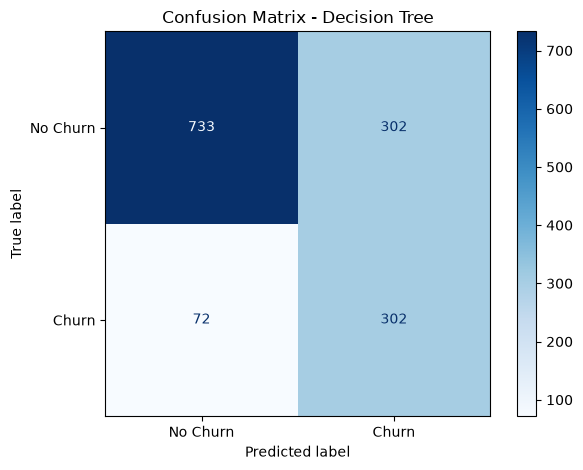

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)

plt.title(f'Confusion Matrix - {best_model_name}')

plt.tight_layout()

plt.show()

## 6. ROC-AUC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates model performance across different classification thresholds.

- **False Positive Rate (FPR):** Proportion of non-churn customers incorrectly classified as churn.
- **True Positive Rate (TPR):** Proportion of churn customers correctly identified.
- **ROC-AUC:** Measures the model's ability to distinguish between churn and non-churn customers.

An AUC value closer to 1 indicates better classification performance, while an AUC of 0.5 represents random classification. The ROC curves below compare the performance of all trained models.import matplotlib.pyplot as plt

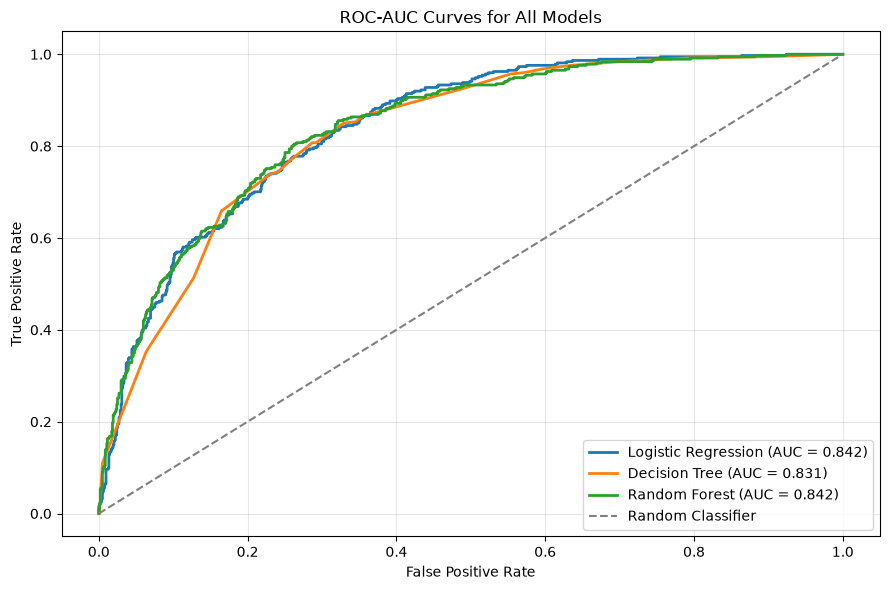

In [35]:
# Plot ROC-AUC curves for all trained models

plt.figure(figsize=(9, 6))

for model_name, roc_info in roc_data.items():
    plt.plot(
        roc_info['fpr'],
        roc_info['tpr'],
        linewidth=2,
        label=f"{model_name} (AUC = {roc_info['auc']:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# ==========================================
# SAVE BEST MODEL
# ==========================================

file_name = best_model_name.replace(" ", "_").lower()

model_path = f'models/{file_name}_baseline.pkl'

joblib.dump(best_model, model_path)

print("Best model saved successfully!")
print("Model:", best_model_name)
print("Recall:", f"{best_recall:.4f}")
print("Saved at:", model_path)

Best model saved successfully!
Model: Decision Tree
Recall: 0.8075
Saved at: models/decision_tree_baseline.pkl


In [37]:
import os

print(os.path.exists('models/decision_tree_baseline.pkl'))
print(os.listdir('models'))

True
['decision_tree_baseline.pkl', 'ohe.pkl', 'scaler.pkl']


In [38]:
# ==========================================
# ERROR ANALYSIS
# ==========================================

predictions = best_model.predict(X_test_final)

errors_df = X_test.copy()

errors_df['Actual_Churn'] = y_test
errors_df['Predicted_Churn'] = predictions

# False Negatives
false_negatives = errors_df[
    (errors_df['Actual_Churn'] == 1) &
    (errors_df['Predicted_Churn'] == 0)
]

# False Positives
false_positives = errors_df[
    (errors_df['Actual_Churn'] == 0) &
    (errors_df['Predicted_Churn'] == 1)
]

false_negatives.to_csv(
    'outputs/false_negatives.csv',
    index=False
)

false_positives.to_csv(
    'outputs/false_positives.csv',
    index=False
)

print("Error analysis saved successfully!")
print("False Negatives:", len(false_negatives))
print("False Positives:", len(false_positives))

Error analysis saved successfully!
False Negatives: 72
False Positives: 302
